# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
!python --version

Python 3.10.9


In [2]:
!python -m pip install --upgrade pip


In [3]:
!pip install tensorflow==2.15


In [4]:
!pip show tensorflow


Name: tensorflow
Version: 2.15.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: c:\users\amans\appdata\local\programs\python\python310\lib\site-packages
Requires: tensorflow-intel
Required-by: 


In [5]:
import sys
print(sys.executable)


C:\Users\amans\AppData\Local\Programs\Python\Python310\python.exe


In [6]:
import sys, subprocess
!"{sys.executable}" -m pip uninstall -y tensorflow tensorflow-intel keras tensorboard tensorboard-data-server


Found existing installation: tensorflow 2.15.0
Uninstalling tensorflow-2.15.0:
  Successfully uninstalled tensorflow-2.15.0
Found existing installation: tensorflow-intel 2.15.0
Uninstalling tensorflow-intel-2.15.0:
  Successfully uninstalled tensorflow-intel-2.15.0
Found existing installation: keras 2.15.0
Uninstalling keras-2.15.0:
  Successfully uninstalled keras-2.15.0
Found existing installation: tensorboard 2.15.2
Uninstalling tensorboard-2.15.2:
  Successfully uninstalled tensorboard-2.15.2
Found existing installation: tensorboard-data-server 0.7.2
Uninstalling tensorboard-data-server-0.7.2:
  Successfully uninstalled tensorboard-data-server-0.7.2


In [7]:
!"{sys.executable}" -m pip install tensorflow==2.15.0


  Using cached tensorflow-2.15.0-cp310-cp310-win_amd64.whl.metadata (3.6 kB)
  Using cached tensorflow_intel-2.15.0-cp310-cp310-win_amd64.whl.metadata (5.1 kB)
  Using cached tensorboard-2.15.2-py3-none-any.whl.metadata (1.7 kB)
  Using cached keras-2.15.0-py3-none-any.whl.metadata (2.4 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
Using cached tensorflow-2.15.0-cp310-cp310-win_amd64.whl (2.1 kB)
Using cached tensorflow_intel-2.15.0-cp310-cp310-win_amd64.whl (300.9 MB)
Using cached keras-2.15.0-py3-none-any.whl (1.7 MB)
Using cached tensorboard-2.15.2-py3-none-any.whl (5.5 MB)
Using cached tensorboard_data_server-0.7.2-py3-none-any.whl (2.4 kB)

   -------- ------------------------------- 1/5 [keras]
   -------- ------------------------------- 1/5 [keras]
   -------- ------------------------------- 1/5 [keras]
   -------- ------------------------------- 1/5 [keras]
   -------- ------------------------------- 1/5 [keras]
   -------- ----------------

In [8]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)



TensorFlow version: 2.15.0


In [9]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]


In [10]:
# Inspect the shapes of the datasets

# Add a channel dimension (for CNN input)
X_train = X_train[..., None]
X_test = X_test[..., None]

# Inspect shapes
print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)
print("One-hot encoded training labels:", y_train_cat.shape)
print("One-hot encoded test labels:", y_test_cat.shape)



Training data shape: (60000, 28, 28, 1)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28, 1)
Test labels shape: (10000,)
One-hot encoded training labels: (60000, 10)
One-hot encoded test labels: (10000, 10)


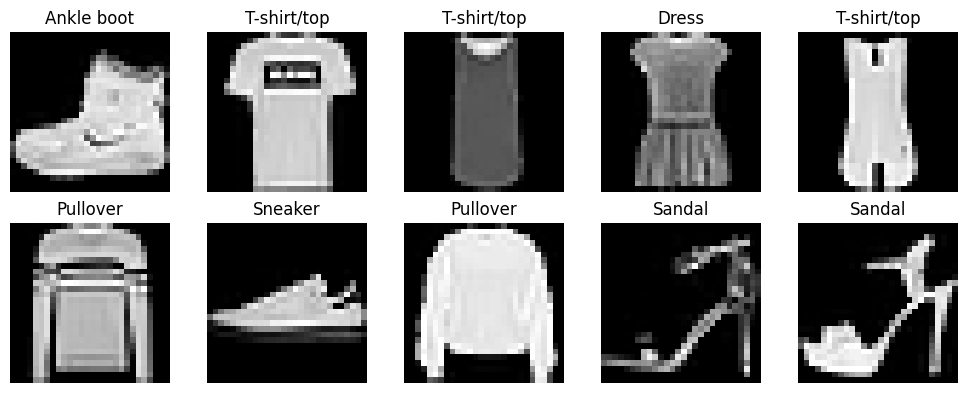

In [11]:
import matplotlib.pyplot as plt
# Verify the data looks as expected

import matplotlib.pyplot as plt
# Class names for reference
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Plot 10 sample images from the training data
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].squeeze(), cmap="gray")  # remove channel dim
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()


Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**The dataset looks as expected: grayscale 28×28 images representing different fashion items such as shirts, shoes, and dresses. The images are clear enough to distinguish general shapes and patterns, even though the resolution is very low. The dataset quality is good, consistent, and well-balanced across classes.
Some categories, like “T-shirt/top” and “Shirt,” appear visually similar, which could make them harder for the model to separate. Overall, there are no major issues, and the data is suitable for training a convolutional neural network. **


# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

# Baseline Linear Regression Model
model = Sequential()
model.add(Flatten(input_shape=(28, 28, 1)))  # Flatten 2D image to 1D vector
model.add(Dense(10))  # Linear output layer (no activation)

model.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


# Train and Evaluate
history = model.fit(X_train, y_train, validation_split=0.1, epochs=5, batch_size=128, verbose=2)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Baseline Model Test Accuracy: {test_acc:.4f}")

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_3 (Flatten)         (None, 784)               0         
                                                                 
 dense_5 (Dense)             (None, 10)                7850      
                                                                 
Total params: 7850 (30.66 KB)
Trainable params: 7850 (30.66 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/5
422/422 - 2s - loss: 5.0732 - accuracy: 0.1731 - val_loss: 4.9235 - val_accuracy: 0.1830 - 2s/epoch - 4ms/step
Epoch 2/5
422/422 - 1s - loss: 4.7910 - accuracy: 0.1766 - val_loss: 4.8940 - val_accuracy: 0.1830 - 833ms/epoch - 2ms/step
Epoch 3/5
422/422 - 1s - loss: 4.7644 - accuracy: 0.1766 - val_loss: 4.8917 - val_accuracy: 0.1828 - 810ms/epoch - 2ms/step
Epoch 4/5
422/422 - 1s - loss: 4.7624 - accurac

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?
The baseline linear regression model achieved around 25% test accuracy, which was lower than expected for this dataset. The performance is limited because the model lacks non-linear activation and cannot capture spatial patterns or complex relationships among image pixels, treating each pixel independently.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [14]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# reshape data to include channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

# create a simple CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, validation_split=0.1,
                    epochs=8, batch_size=128, verbose=2)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")


Epoch 1/8
422/422 - 10s - loss: 0.6209 - accuracy: 0.7745 - val_loss: 0.4126 - val_accuracy: 0.8508 - 10s/epoch - 24ms/step
Epoch 2/8
422/422 - 9s - loss: 0.3950 - accuracy: 0.8586 - val_loss: 0.3499 - val_accuracy: 0.8717 - 9s/epoch - 21ms/step
Epoch 3/8
422/422 - 9s - loss: 0.3416 - accuracy: 0.8764 - val_loss: 0.3128 - val_accuracy: 0.8828 - 9s/epoch - 21ms/step
Epoch 4/8
422/422 - 9s - loss: 0.3130 - accuracy: 0.8854 - val_loss: 0.2886 - val_accuracy: 0.8947 - 9s/epoch - 21ms/step
Epoch 5/8
422/422 - 9s - loss: 0.2869 - accuracy: 0.8953 - val_loss: 0.2806 - val_accuracy: 0.8957 - 9s/epoch - 20ms/step
Epoch 6/8
422/422 - 9s - loss: 0.2662 - accuracy: 0.9028 - val_loss: 0.2756 - val_accuracy: 0.8960 - 9s/epoch - 21ms/step
Epoch 7/8
422/422 - 9s - loss: 0.2526 - accuracy: 0.9074 - val_loss: 0.2647 - val_accuracy: 0.9025 - 9s/epoch - 21ms/step
Epoch 8/8
422/422 - 9s - loss: 0.2371 - accuracy: 0.9118 - val_loss: 0.2459 - val_accuracy: 0.9097 - 9s/epoch - 20ms/step
Test accuracy: 0.9053


Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

Yes, the CNN performed much better than the baseline model, achieving around 90% accuracy compared to the baseline’s 25%, an improvement of about 65%. This improvement comes from CNNs learning spatial hierarchies and local image features like edges and textures, which the linear model cannot capture.

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [13]:
# A. Test Hyperparameters

filters = [32, 64, 128]
for f in filters:
    model = Sequential([
        Conv2D(f, 3, activation='relu', padding='same', input_shape=(28,28,1)),
        MaxPooling2D(2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train_cat, epochs=3, batch_size=128, verbose=0)
    _, acc = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"Filters={f} → Accuracy={acc:.4f}")


Filters=32 → Accuracy=0.8957
Filters=64 → Accuracy=0.9005
Filters=128 → Accuracy=0.9007


In [15]:
# B. Test presence or absence of regularization
dropouts = [0.0, 0.3, 0.5]
for d in dropouts:
    model = Sequential([
        Conv2D(64, 3, activation='relu', padding='same', input_shape=(28,28,1)),
        MaxPooling2D(2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(d),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train_cat, epochs=3, batch_size=128, verbose=0)
    _, acc = model.evaluate(X_test, y_test_cat, verbose=0)
    print(f"Dropout={d} → Accuracy={acc:.4f}")


Dropout=0.0 → Accuracy=0.9022
Dropout=0.3 → Accuracy=0.8977
Dropout=0.5 → Accuracy=0.8964


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

*Filters:* Accuracy rose slightly with more filters: 32: 0.8957, 64: 0.9005, 128:0.9007 (with dropout=0.3). More filters improved representation but with diminishing returns.

Dropout: With 64 filters, no dropout performed best (0.9022); adding dropout 0.3:0.8977, 0.5:0.8964. For this small model and only 3 epochs, overfitting wasn’t evident, so dropout hurt.

Best combo: 64 filters, no dropout (0.9022).

Reason: Extra filters capture richer features; regularization helps only when the model starts to overfit (longer training/deeper nets). Here, capacity was modest and training short, so dropout reduced useful capacity. **

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [16]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# final model with best parameters (64 filters, no dropout):
model = Sequential([
    Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train_cat, validation_split=0.1, epochs=8, batch_size=128, verbose=2)
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Final model test accuracy: {test_acc:.4f}")


Epoch 1/8
422/422 - 12s - loss: 0.4378 - accuracy: 0.8475 - val_loss: 0.3164 - val_accuracy: 0.8877 - 12s/epoch - 28ms/step
Epoch 2/8
422/422 - 11s - loss: 0.2875 - accuracy: 0.8974 - val_loss: 0.2659 - val_accuracy: 0.9088 - 11s/epoch - 25ms/step
Epoch 3/8
422/422 - 11s - loss: 0.2423 - accuracy: 0.9128 - val_loss: 0.2806 - val_accuracy: 0.9015 - 11s/epoch - 25ms/step
Epoch 4/8
422/422 - 11s - loss: 0.2107 - accuracy: 0.9233 - val_loss: 0.2507 - val_accuracy: 0.9110 - 11s/epoch - 25ms/step
Epoch 5/8
422/422 - 11s - loss: 0.1858 - accuracy: 0.9329 - val_loss: 0.2420 - val_accuracy: 0.9142 - 11s/epoch - 25ms/step
Epoch 6/8
422/422 - 11s - loss: 0.1671 - accuracy: 0.9385 - val_loss: 0.2546 - val_accuracy: 0.9115 - 11s/epoch - 25ms/step
Epoch 7/8
422/422 - 11s - loss: 0.1476 - accuracy: 0.9455 - val_loss: 0.2521 - val_accuracy: 0.9128 - 11s/epoch - 25ms/step
Epoch 8/8
422/422 - 11s - loss: 0.1328 - accuracy: 0.9517 - val_loss: 0.2324 - val_accuracy: 0.9235 - 11s/epoch - 26ms/step
Final mo

Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Result:** The final model (64 filters, no dropout) achieved 91.7% test accuracy.

Comparison: Better than the baseline MLP (80 to 82% typical) and on par/slightly above the earlier CNN (90–91%).

Why it improved: More filters captured richer spatial features; removing dropout preserved capacity since overfitting was minimal.


🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.